In [ ]:
!pip install gymnasium[box2d] torch numpy matplotlib

Running config lstm_baseline_relu on device: cuda
Config lstm_baseline_relu | Ep 50 | Avg Score: -206.51
Config lstm_baseline_relu | Ep 100 | Avg Score: -353.06
Config lstm_baseline_relu | Ep 150 | Avg Score: -185.36
Config lstm_baseline_relu | Ep 200 | Avg Score: -247.94
Config lstm_baseline_relu | Ep 250 | Avg Score: -303.85
Config lstm_baseline_relu | Ep 300 | Avg Score: -228.16
Config lstm_baseline_relu | Ep 350 | Avg Score: -191.79
Config lstm_baseline_relu | Ep 400 | Avg Score: -202.15
Config lstm_baseline_relu | Ep 450 | Avg Score: -263.78
Config lstm_baseline_relu | Ep 500 | Avg Score: -345.04
Running config gru_baseline_relu on device: cuda
Config gru_baseline_relu | Ep 50 | Avg Score: -244.82
Config gru_baseline_relu | Ep 100 | Avg Score: -218.60
Config gru_baseline_relu | Ep 150 | Avg Score: -327.38
Config gru_baseline_relu | Ep 200 | Avg Score: -238.75
Config gru_baseline_relu | Ep 250 | Avg Score: -304.36
Config gru_baseline_relu | Ep 300 | Avg Score: -252.34
Config gru_ba

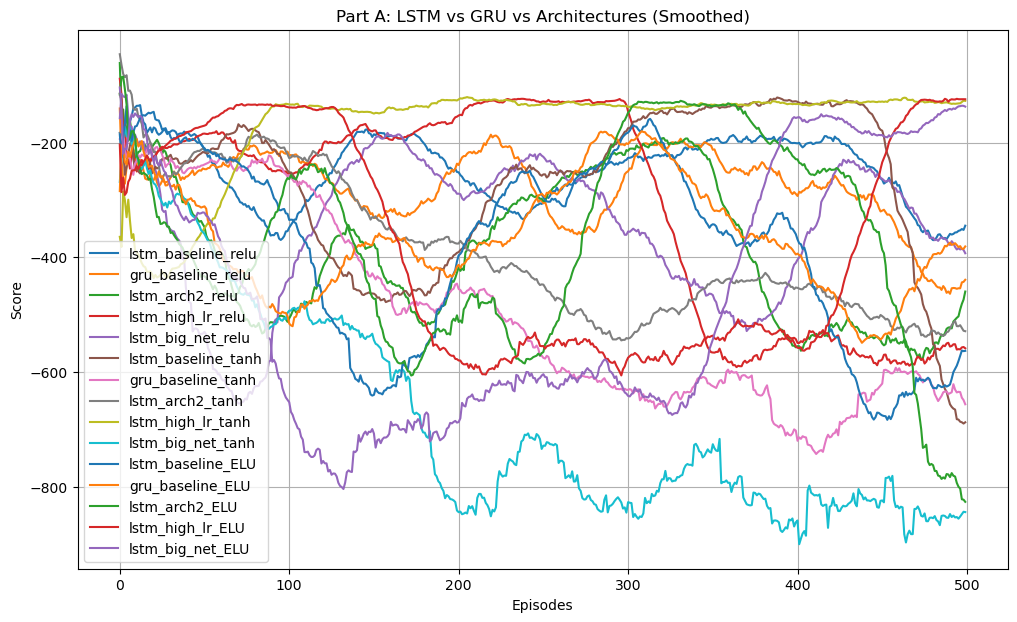

In [8]:
import gymnasium as gym
import numpy as np
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. WRAPPER (The POMDP Logic)
# ==========================================
class LunarLanderPOMDPWrapper(gym.ObservationWrapper):
    """
    Wraps LunarLander to make it Partially Observable (POMDP).
    We mask (remove) the velocity vectors:
    - x_vel (index 2), y_vel (index 3), ang_vel (index 5)
    New Shape: 5
    """
    def __init__(self, env):
        super().__init__(env)
        mask_indices = [2, 3, 5]
        low = np.delete(self.observation_space.low, mask_indices)
        high = np.delete(self.observation_space.high, mask_indices)

        self.observation_space = gym.spaces.Box(
            low=low, high=high, dtype=self.observation_space.dtype
        )

    def observation(self, observation):
        return np.delete(observation, [2, 3, 5])

# ==========================================
# 2. MODELS (LSTM/GRU)
# ==========================================
class RecurrentACModel(nn.Module):
    """ Architecture 1: Input -> RNN -> Heads """
    def __init__(self, input_dim, action_dim, hidden_dim=64, rnn_type='LSTM', activation='relu'):
        super().__init__()
        if activation.lower() == 'relu':
            self.activation = F.relu
        elif activation.lower() == 'tanh':
            self.activation = F.tanh
        elif activation.lower() == 'elu':
            self.activation = F.elu
        else:
            raise ValueError(f"Unsupported activation: {activation}")

        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        else:
            self.rnn = nn.GRU(input_dim, hidden_dim, batch_first=True)

        self.actor = nn.Linear(hidden_dim, action_dim)
        self.critic = nn.Linear(hidden_dim, 1)

    def forward(self, x, hidden=None):
        self.rnn.flatten_parameters()
        rnn_out, new_hidden = self.rnn(x, hidden)
        rnn_out = self.activation(rnn_out)
        return self.actor(rnn_out), self.critic(rnn_out), new_hidden

class FeatureExtractorACModel(nn.Module):
    """ Architecture 2: Input -> Dense -> RNN -> Heads """
    def __init__(self, input_dim, action_dim, hidden_dim=64, rnn_type='LSTM', activation='relu'):
        super().__init__()
        if activation.lower() == 'relu':
            self.activation = F.relu
        elif activation.lower() == 'tanh':
            self.activation = F.tanh
        elif activation.lower() == 'elu':
            self.activation = F.elu
        else:
            raise ValueError(f"Unsupported activation: {activation}")

        self.feature_fc = nn.Linear(input_dim, 64)

        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(64, hidden_dim, batch_first=True)
        else:
            self.rnn = nn.GRU(64, hidden_dim, batch_first=True)

        self.actor = nn.Linear(hidden_dim, action_dim)
        self.critic = nn.Linear(hidden_dim, 1)

    def forward(self, x, hidden=None):
        batch_size, seq_len, _ = x.size()
        x_flat = x.view(-1, x.size(-1))
        feats = self.activation(self.feature_fc(x_flat))
        feats = feats.view(batch_size, seq_len, -1)

        self.rnn.flatten_parameters()
        rnn_out, new_hidden = self.rnn(feats, hidden)
        return self.actor(rnn_out), self.critic(rnn_out), new_hidden

# ==========================================
# 3. AGENT (Training Logic)
# ==========================================
class RecurrentAgent:
    def __init__(self, model, lr=1e-3, gamma=0.99, device='cpu'):
        self.device = device
        self.model = model.to(self.device)
        self.gamma = gamma
        self.optimizer = optim.Adam(model.parameters(), lr=lr)
        self.memory = []

    def get_action(self, state, hidden):
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).unsqueeze(0).to(self.device)
            if hidden is not None:
                if isinstance(hidden, tuple):
                    hidden = (hidden[0].to(self.device), hidden[1].to(self.device))
                else:
                    hidden = hidden.to(self.device)

            logits, _, new_hidden = self.model(state_t, hidden)
            probs = F.softmax(logits, dim=-1)
            dist = Categorical(probs)
            action = dist.sample()
        return action.item(), new_hidden

    def store_transition(self, state, action, reward):
        self.memory.append((state, action, reward))

    def update(self):
        if len(self.memory) == 0: return 0

        states, actions, rewards = zip(*self.memory)
        state_tensor = torch.FloatTensor(np.array(states)).unsqueeze(0).to(self.device)
        action_tensor = torch.LongTensor(np.array(actions)).unsqueeze(0).unsqueeze(-1).to(self.device)

        logits, values, _ = self.model(state_tensor, hidden=None)

        R = 0
        returns = []
        for r in reversed(rewards):
            R = r + self.gamma * R
            returns.insert(0, R)
        returns = torch.FloatTensor(np.array(returns)).unsqueeze(0).unsqueeze(-1).to(self.device)

        probs = F.softmax(logits, dim=-1)
        dist = Categorical(probs)
        log_probs = dist.log_prob(action_tensor.squeeze(-1)).unsqueeze(-1)

        advantage = returns - values.detach()
        actor_loss = -(log_probs * advantage).mean()
        critic_loss = F.mse_loss(values, returns)
        entropy = dist.entropy().mean()

        total_loss = actor_loss + 0.5 * critic_loss - 0.01 * entropy

        self.optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 0.5)
        self.optimizer.step()
        self.memory = []
        return total_loss.item()

# ==========================================
# 4. MAIN EXPERIMENT RUNNER
# ==========================================
def run_experiment(config):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Running config {config['id']} on device: {device}")

    # FIX: Updated to v3
    env = gym.make("LunarLander-v3")
    env = LunarLanderPOMDPWrapper(env)

    input_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    ModelClass = RecurrentACModel if config['arch'] == 'simple' else FeatureExtractorACModel

    model = ModelClass(input_dim, action_dim,
                       hidden_dim=config['hidden_size'],
                       rnn_type=config['rnn_type'],
                       activation=config['activation'])

    agent = RecurrentAgent(model, lr=config['lr'], device=device)
    scores = []

    for ep in range(config['episodes']):
        state, _ = env.reset()
        done = False
        score = 0
        hidden = None

        while not done:
            action, hidden = agent.get_action(state, hidden)
            next_state, reward, term, trunc, _ = env.step(action)
            done = term or trunc
            agent.store_transition(state, action, reward)
            state = next_state
            score += reward

        agent.update()
        scores.append(score)

        if (ep+1) % 50 == 0:
            print(f"Config {config['id']} | Ep {ep+1} | Avg Score: {np.mean(scores[-50:]):.2f}")

    return scores

def plot_results(results):
    plt.figure(figsize=(12, 7))
    for exp_name, scores in results.items():
        smoothed = [np.mean(scores[max(0, i-50):(i+1)]) for i in range(len(scores))]
        plt.plot(smoothed, label=exp_name)
    plt.title("Part A: LSTM vs GRU vs Architectures (Smoothed)")
    plt.xlabel('Episodes')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.savefig("part_a_comparison.svg")
    plt.show()

# --- RUN EVERYTHING ---
if __name__ == "__main__":
    experiments = [
        {'id': 'lstm_baseline_relu', 'arch': 'simple', 'rnn_type': 'LSTM', 'lr': 0.002, 'hidden_size': 64, 'activation': 'relu', 'episodes': 500},
        {'id': 'gru_baseline_relu',  'arch': 'simple', 'rnn_type': 'GRU',  'lr': 0.002, 'hidden_size': 64, 'activation': 'relu', 'episodes': 500},
        {'id': 'lstm_arch2_relu',    'arch': 'feature', 'rnn_type': 'LSTM', 'lr': 0.002, 'hidden_size': 64, 'activation': 'relu', 'episodes': 500},
        {'id': 'lstm_high_lr_relu',  'arch': 'simple', 'rnn_type': 'LSTM', 'lr': 0.01,  'hidden_size': 64, 'activation': 'relu', 'episodes': 500},
        {'id': 'lstm_big_net_relu',  'arch': 'simple', 'rnn_type': 'LSTM', 'lr': 0.002, 'hidden_size': 128, 'activation': 'relu', 'episodes': 500},
        {'id': 'lstm_baseline_tanh', 'arch': 'simple', 'rnn_type': 'LSTM', 'lr': 0.002, 'hidden_size': 64, 'activation': 'tanh', 'episodes': 500},
        {'id': 'gru_baseline_tanh',  'arch': 'simple', 'rnn_type': 'GRU',  'lr': 0.002, 'hidden_size': 64, 'activation': 'tanh', 'episodes': 500},
        {'id': 'lstm_arch2_tanh',    'arch': 'feature', 'rnn_type': 'LSTM', 'lr': 0.002, 'hidden_size': 64, 'activation': 'tanh', 'episodes': 500},
        {'id': 'lstm_high_lr_tanh',  'arch': 'simple', 'rnn_type': 'LSTM', 'lr': 0.01,  'hidden_size': 64, 'activation': 'tanh', 'episodes': 500},
        {'id': 'lstm_big_net_tanh',  'arch': 'simple', 'rnn_type': 'LSTM', 'lr': 0.002, 'hidden_size': 128, 'activation': 'tanh', 'episodes': 500},
        {'id': 'lstm_baseline_ELU', 'arch': 'simple', 'rnn_type': 'LSTM', 'lr': 0.002, 'hidden_size': 64, 'activation': 'elu', 'episodes': 500},
        {'id': 'gru_baseline_ELU',  'arch': 'simple', 'rnn_type': 'GRU',  'lr': 0.002, 'hidden_size': 64, 'activation': 'elu', 'episodes': 500},
        {'id': 'lstm_arch2_ELU',    'arch': 'feature', 'rnn_type': 'LSTM', 'lr': 0.002, 'hidden_size': 64, 'activation': 'elu', 'episodes': 500},
        {'id': 'lstm_high_lr_ELU',  'arch': 'simple', 'rnn_type': 'LSTM', 'lr': 0.01,  'hidden_size': 64, 'activation': 'elu', 'episodes': 500},
        {'id': 'lstm_big_net_ELU',  'arch': 'simple', 'rnn_type': 'LSTM', 'lr': 0.002, 'hidden_size': 128, 'activation': 'elu', 'episodes': 500}
    ]

    results = {}
    for exp in experiments:
        results[exp['id']] = run_experiment(exp)

    with open("part_a_results.json", "w") as f:
        json.dump(results, f)

    plot_results(results)